In [1]:
import pandas as pd
import numpy as np
import os
import cv2
from skimage.feature import hog
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from time import time

print("Libraries imported successfully!")

# Load the preprocessed data
processed_data = joblib.load('../models/processed_data.pkl')
label_encoder = joblib.load('../models/label_encoder.pkl')

X_train = processed_data['X_train']
X_test = processed_data['X_test']
y_train = processed_data['y_train']
y_test = processed_data['y_test']
category_names = processed_data['category_names']

print("Data loaded successfully!")
print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Categories: {category_names}")

Libraries imported successfully!
Data loaded successfully!
Training data shape: (6400, 60, 80, 3)
Test data shape: (1600, 60, 80, 3)
Categories: ['Dresses' 'Jackets' 'Pants' 'Shirts' 'Shoes' 'Sweaters' 'Tops' 'Tshirts']


In [2]:
def extract_hog_features(images):
    # Extracting HOG features from images
    hog_features = []

    
    for i, img in enumerate(images):
        # Converting to grayscale for HOG
        gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
        
        # Extract HOG features
        features = hog(gray, 
                      pixels_per_cell=(8, 8), 
                      cells_per_block=(2, 2),
                      visualize=False,
                      feature_vector=True)
        hog_features.append(features)
        

    return np.array(hog_features)

def extract_color_features(images):
    # Extract color histogram features
    color_features = []

    
    for i, img in enumerate(images):
        # Converting to HSV for better color representation
        img_uint8 = (img * 255).astype(np.uint8)
        hsv = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2HSV)
        
        # Color histograms for each channel
        hist_h = cv2.calcHist([hsv], [0], None, [8], [0, 180]).flatten()
        hist_s = cv2.calcHist([hsv], [1], None, [8], [0, 256]).flatten()
        hist_v = cv2.calcHist([hsv], [2], None, [8], [0, 256]).flatten()
        
        # Combine all features
        color_feat = np.concatenate([hist_h, hist_s, hist_v])
        color_features.append(color_feat)
        

    return np.array(color_features)

In [3]:
start_time = time()

# Extract HOG features
X_train_hog = extract_hog_features(X_train)
print(f"HOG features shape: {X_train_hog.shape}")

# Extract color features
X_train_color = extract_color_features(X_train)
print(f"Color features shape: {X_train_color.shape}")

# Combine features
X_train_combined = np.concatenate([X_train_hog, X_train_color], axis=1)
print(f"Combined features shape: {X_train_combined.shape}")

feature_extraction_time = time() - start_time
print(f"Feature extraction completed in {feature_extraction_time:.2f} seconds")

HOG features shape: (6400, 1944)
Color features shape: (6400, 24)
Combined features shape: (6400, 1968)
Feature extraction completed in 24.61 seconds


In [4]:
print("Training Random Forest model:-")
start_time = time()

# Initializing model with parameters
rf_model = RandomForestClassifier(
    n_estimators=100,           # no. of trees
    max_depth=20,               # Maximum depth of trees
    min_samples_split=5,        # Minimum samples to split a node
    min_samples_leaf=2,         # Minimum samples at a leaf node
    max_features='sqrt',        # Number of features for best split
    random_state=42,            # For reproducibility
    n_jobs=-1,                  # Use all available cores
    verbose=1                   # Show training progress
)

# Training the model
rf_model.fit(X_train_combined, y_train)

training_time = time() - start_time
print(f"Random Forest training completed in {training_time:.2f} seconds")
print(f"Number of trees: {len(rf_model.estimators_)}")

Training Random Forest model:-


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    2.8s


Random Forest training completed in 8.25 seconds
Number of trees: 100


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    8.0s finished


In [5]:
print("Evaluating on training data...")

# Prediction on training data
y_train_pred = rf_model.predict(X_train_combined)
train_accuracy = accuracy_score(y_train, y_train_pred)

print(f"Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")

# Feature importance
feature_importance = rf_model.feature_importances_
print(f"Feature importance range: {feature_importance.min():.4f} - {feature_importance.max():.4f}")
print(f"Number of features: {len(feature_importance)}")

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s


Evaluating on training data...


[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


Training Accuracy: 0.9986 (99.86%)
Feature importance range: 0.0000 - 0.0167
Number of features: 1968


In [6]:
# Evaluating on test data
start_time = time()

# Extract features from test data
X_test_hog = extract_hog_features(X_test)
X_test_color = extract_color_features(X_test)
X_test_combined = np.concatenate([X_test_hog, X_test_color], axis=1)

# Predict on test data
y_test_pred = rf_model.predict(X_test_combined)
test_accuracy = accuracy_score(y_test, y_test_pred)

test_time = time() - start_time
print(f"Test evaluation completed in {test_time:.2f} seconds")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

Test evaluation completed in 6.42 seconds
Test Accuracy: 0.8756 (87.56%)


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


PERFORMANCE ANALYSIS:-


ACCURACY SCORES:
Training Accuracy: 0.9986 (99.86%)
Test Accuracy:     0.8756 (87.56%)

TIME TAKEN:
Feature extraction: 24.61 seconds
Model training:     8.25 seconds
Test evaluation:    6.42 seconds

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

     Dresses       0.82      0.92      0.87       160
     Jackets       1.00      0.11      0.20        18
       Pants       1.00      0.97      0.98       128
      Shirts       0.88      0.82      0.85       208
       Shoes       1.00      1.00      1.00       470
    Sweaters       1.00      0.03      0.05        36
        Tops       0.65      0.45      0.54       132
     Tshirts       0.80      0.96      0.87       448

    accuracy                           0.88      1600
   macro avg       0.89      0.66      0.67      1600
weighted avg       0.88      0.88      0.86      1600



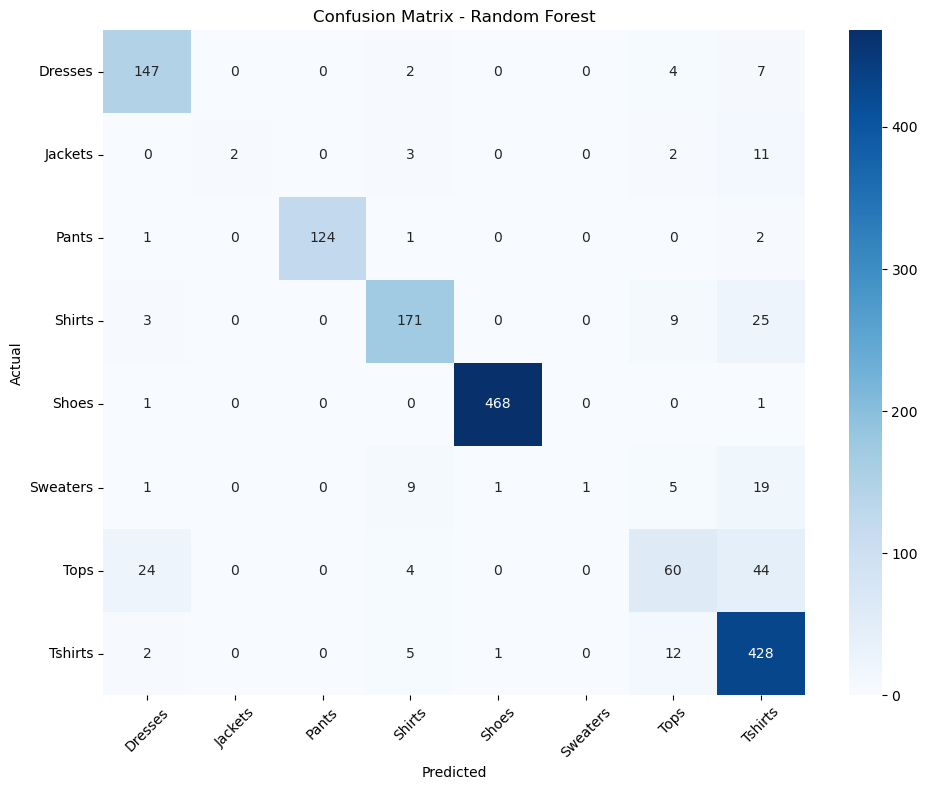

In [7]:
print("PERFORMANCE ANALYSIS:-\n")


print(f"\nACCURACY SCORES:")
print(f"Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy:     {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

print(f"\nTIME TAKEN:")
print(f"Feature extraction: {feature_extraction_time:.2f} seconds")
print(f"Model training:     {training_time:.2f} seconds")
print(f"Test evaluation:    {test_time:.2f} seconds")

print(f"\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_test_pred, target_names=category_names))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=category_names, yticklabels=category_names)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

FEATURE IMPORTANCE ANALYSIS:-

Top 10 most important features:
      feature_index  importance
1849           1849    0.016667
572             572    0.012892
936             936    0.012582
1543           1543    0.012365
600             600    0.011253
900             900    0.010839
480             480    0.010809
1840           1840    0.010535
594             594    0.009677
880             880    0.009103


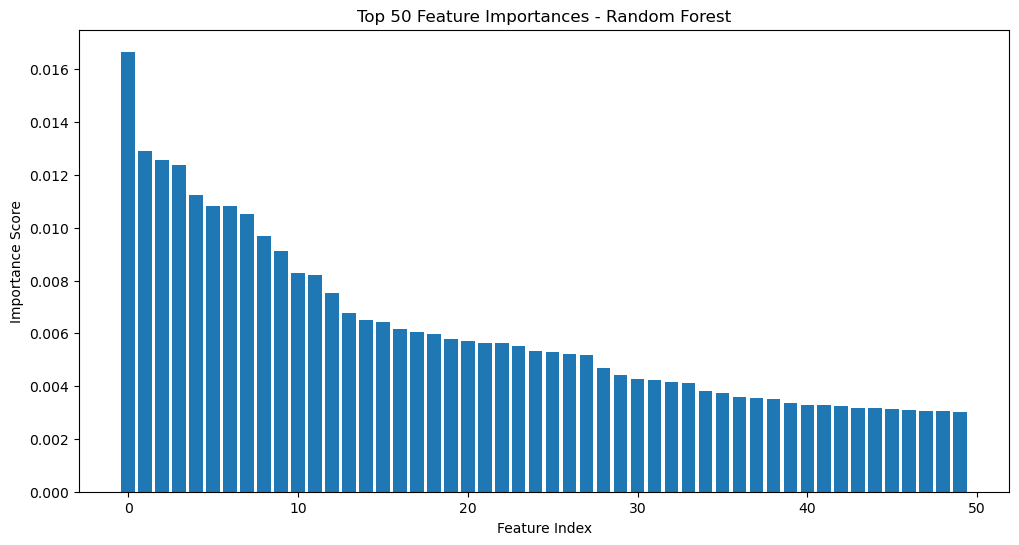


Number of important features (importance > 0.001): 177
Total number of features: 1968


In [8]:
# Analyze feature importance
print("FEATURE IMPORTANCE ANALYSIS:-\n")

# Get feature importance scores
importance_df = pd.DataFrame({
    'feature_index': range(len(feature_importance)),
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print(f"Top 10 most important features:")
print(importance_df.head(10))

# Plot feature importance
plt.figure(figsize=(12, 6))
plt.bar(range(50), importance_df['importance'].head(50))
plt.title('Top 50 Feature Importances - Random Forest')
plt.xlabel('Feature Index')
plt.ylabel('Importance Score')
plt.show()

# Calculate how many features are actually important
important_features = importance_df[importance_df['importance'] > 0.001]
print(f"\nNumber of important features (importance > 0.001): {len(important_features)}")
print(f"Total number of features: {len(feature_importance)}")

In [9]:
# Save the trained model
model_data = {
    'model': rf_model,
    'feature_importance': feature_importance,
    'training_accuracy': train_accuracy,
    'test_accuracy': test_accuracy,
    'feature_indices': {
        'hog_start': 0,
        'hog_end': X_train_hog.shape[1],
        'color_start': X_train_hog.shape[1],
        'color_end': X_train_combined.shape[1]
    }
}

joblib.dump(model_data, '../models/random_forest_model.pkl')
print("Random Forest model saved successfully!!!!")

# Saving feature matrices for comparison with CNN
feature_data = {
    'X_train_combined': X_train_combined,
    'X_test_combined': X_test_combined,
    'y_train': y_train,
    'y_test': y_test
}

joblib.dump(feature_data, '../models/random_forest_features.pkl')
print("Feature data saved successfully!")

Random Forest model saved successfully!!!!
Feature data saved successfully!


In [10]:
from PIL import Image 

def predict_fashion_image(image, rf_model, label_encoder):

   # This func returns predicted_class, confidence, all_probabilities

    
    # Preprocessing image as in training
    import cv2
    from skimage.feature import hog
    
    # Resize and convert to array
    image_resized = image.resize((80, 60))
    image_array = np.array(image_resized) / 255.0
    
    # Extract HOG features
    gray = cv2.cvtColor((image_array * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    hog_features = hog(gray, pixels_per_cell=(8,8), cells_per_block=(2,2), visualize=False)
    
    # Extract color features
    hsv = cv2.cvtColor((image_array * 255).astype(np.uint8), cv2.COLOR_RGB2HSV)
    hist_h = cv2.calcHist([hsv], [0], None, [8], [0, 180]).flatten()
    hist_s = cv2.calcHist([hsv], [1], None, [8], [0, 256]).flatten()
    hist_v = cv2.calcHist([hsv], [2], None, [8], [0, 256]).flatten()
    color_features = np.concatenate([hist_h, hist_s, hist_v])
    
    # Combine features
    combined_features = np.concatenate([hog_features, color_features]).reshape(1, -1)
    
    # Predict
    probabilities = rf_model.predict_proba(combined_features)[0]
    predicted_class_idx = np.argmax(probabilities)
    predicted_class = label_encoder.inverse_transform([predicted_class_idx])[0]
    confidence = probabilities[predicted_class_idx]
    
    # Get all probabilities
    all_probabilities = {
        label_encoder.inverse_transform([i])[0]: float(prob) 
        for i, prob in enumerate(probabilities)
    }
    
    return predicted_class, confidence, all_probabilities



# Test the prediction function
print("Testing prediction function:-")

# Simple test without PIL conversion
test_features = X_test_combined[0:1]  # Take first test sample
probabilities = rf_model.predict_proba(test_features)[0]
predicted_class_idx = np.argmax(probabilities)
predicted_class = label_encoder.inverse_transform([predicted_class_idx])[0]
confidence = probabilities[predicted_class_idx]


print(f"Sample prediction: {predicted_class} (confidence: {confidence:.4f})")
print("True class:", category_names[y_test[0]])

# Show all probabilities
all_probs = {
    category_names[i]: float(prob) 
    for i, prob in enumerate(probabilities)
}
print("All probabilities:", all_probs)

Testing prediction function:-
Sample prediction: Shoes (confidence: 0.9900)
True class: Shoes
All probabilities: {np.str_('Dresses'): 0.0, np.str_('Jackets'): 0.0, np.str_('Pants'): 0.0, np.str_('Shirts'): 0.0, np.str_('Shoes'): 0.99, np.str_('Sweaters'): 0.0, np.str_('Tops'): 0.01, np.str_('Tshirts'): 0.0}


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


In [11]:
print("RANDOM FOREST TRAINING COMPLETED!!!")


print(f"\nFINAL RESULTS:")
print(f"Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy:     {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")


print(f"\n Dataset Summary:")
print(f"   - Training samples: {X_train.shape[0]}")
print(f"   - Test samples: {X_test.shape[0]}")
print(f"   - Number of features: {X_train_combined.shape[1]}")
print(f"   - Number of categories: {len(category_names)}")
print(f"   - Categories: {list(category_names)}")

print(f"\n Performance Summary:")
print(f"   - Feature extraction time: {feature_extraction_time:.2f}s")
print(f"   - Model training time: {training_time:.2f}s")
print(f"   - Total time: {feature_extraction_time + training_time:.2f}s")


RANDOM FOREST TRAINING COMPLETED!!!

FINAL RESULTS:
Training Accuracy: 0.9986 (99.86%)
Test Accuracy:     0.8756 (87.56%)

 Dataset Summary:
   - Training samples: 6400
   - Test samples: 1600
   - Number of features: 1968
   - Number of categories: 8
   - Categories: [np.str_('Dresses'), np.str_('Jackets'), np.str_('Pants'), np.str_('Shirts'), np.str_('Shoes'), np.str_('Sweaters'), np.str_('Tops'), np.str_('Tshirts')]

 Performance Summary:
   - Feature extraction time: 24.61s
   - Model training time: 8.25s
   - Total time: 32.86s
